# Taken Lars

## 👤 Lars — Verkenning & Beschrijvende Statistiek
**Leerdoelen:** Beschrijvende statistiek + Visualisatie  
**Vragen 1 t/m 5** + bijhorende Python  
**Levert op:** `df_clean`

| # | Type | Taak |
|---|------|------|
| – | 🐍 Python | Dataset inladen → `df` |
| Q1 | ✍️ Schriftelijk | Meetniveau per variabele bepalen |
| Q2 | ✍️ Schriftelijk | Waarom meetniveau vooraf bekijken |
| 1 | 🐍 Python | Beschrijvende statistieken per kolom (`.describe()`, mode, etc.) |
| 2 | 🐍 Python | Detectie + afhandeling missende / extreme waarden → `df_clean` |

| Q3 | ✍️ Schriftelijk | Hoe omgegaan met missende/extreme waarden |
| 3 | 🐍 Python | Visualiseer verdeling van de 2 gekozen onafh. variabelen + afhankelijke (CO₂) → histogrammen/boxplots |
| Q4 | ✍️ Schriftelijk | Beschrijving 3 visualisaties met statistische termen |
| 4 | 🐍 Python | Normaliteitstoets (Shapiro / D'Agostino) op de 3 verdelingen |
| Q5 | ✍️ Schriftelijk | Conclusie m.b.t. de drie verdelingen |

## Python opdrachten

### Data inladen / imports

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [21]:
df = pd.read_excel('Mobiliteitsdata.xlsx').drop('stad', axis=1)
df.isnull().sum()

persoon_ID                               0
geslacht                                 0
leeftijd                                 0
gewicht_KG                               0
burgerlijke_staat                        0
jaarsalaris_eu                           1
huishouden_grootte                       0
provincie                                0
opleiding_niveau                         1
autobezit                                1
fietsbezit                               0
elektrisch_auto                          0
km_auto_per_jaar                         0
km_fiets_per_jaar                        0
km_ov_per_jaar                           0
km_vliegtuig_per_jaar                    0
dagen_thuiswerken_per_week_pro_rato      0
dagen_kantoorwerken_per_week_pro_rato    0
dagen_in_buitenland_per_jaar             0
gebruik_carsharing                       0
co2_uitstoot_per_jaar_KG                 7
dtype: int64

### Python 1.L - beschrijvende statistieken per kolom 

In [19]:
#df.columns
#df.info
#df.dtypes

| Kolom | Naam | Meetniveau | Toelichting |
|-------|------|------------|-------------|
| 1 | persoon_ID | Nominaal | Unieke identifier |
| 2 | geslacht | Nominaal | Categorieën (man/vrouw) zonder rangorde |
| 3 | leeftijd | Ratio | Absoluut nulpunt (0 jaar) |
| 4 | gewicht_KG | Ratio | Absoluut nulpunt (0 kg) |
| 5 | burgerlijke_staat | Nominaal | Categorieën (gehuwd/ongehuwd/etc.) zonder rangorde |
| 6 | jaarsalaris_eu | Ratio | Absoluut nulpunt (€ 0) |
| 7 | huishouden_grootte | Ratio | Aantal mensen |
| 8 | stad | Nominaal | Plaatsnamen als categorie geen rangorde |
| 9 | provincie | Nominaal | Provincienamen als categorie geen rangorde |
| 10 | opleiding_niveau | Ordinaal | Rangorde aanwezig (MBO < HBO < WO) afstanden ongelijk |
| 11 | autobezit | Nominaal | ja/nee, geen rangorde |
| 12 | fietsbezit | Nominaal | ja/nee, geen rangorde |
| 13 | elektrisch_auto | Nominaal | ja/nee, geen rangorde |
| 14 | km_auto_per_jaar | Ratio | Absoluut nulpunt (0 km) |
| 15 | km_fiets_per_jaar | Ratio | Absoluut nulpunt (0 km) |
| 16 | km_ov_per_jaar | Ratio | Absoluut nulpunt (0 km) |
| 17 | km_vliegtuig_per_jaar | Ratio | Absoluut nulpunt (0 km) |
| 18 | dagen_thuiswerken_per_week_pro_rato | Ratio | Telbaar 0 = geen thuiswerkdag |
| 19 | dagen_kantoorwerken_per_week_pro_rato | Ratio | Telbaar 0 = geen kantoordag |
| 20 | dagen_in_buitenland_per_jaar | Ratio | Telbaar absoluut nulpunt (0 dagen) |
| 21 | gebruik_carsharing | Ordinaal | Rangorde (Nooit < Heel soms < Soms < Vaak < Altijd) |
| 22 | co2_uitstoot_per_jaar_KG | Ratio | Absoluut nulpunt (0 kg CO₂) |

### Python 2.L - Ga na of er missende/niet kloppende/extreme waarden zijn in de dataset en ga hier op een adequate manier mee om.

In [23]:
# Missende waarden per kolom met de juiste methode
mediaan_cols = ["leeftijd", "gewicht_KG", "jaarsalaris_eu", "km_auto_per_jaar",
                "km_fiets_per_jaar", "km_ov_per_jaar", "km_vliegtuig_per_jaar",
                "co2_uitstoot_per_jaar_KG", 'huishouden_grootte', "dagen_in_buitenland_per_jaar", "dagen_kantoorwerken_per_week_pro_rato", ]
modus_cols = ["geslacht", "burgerlijke_staat", "provincie",
              "opleiding_niveau", "autobezit", "fietsbezit", "elektrisch_auto",
             "gebruik_carsharing"]

for col in mediaan_cols:
    df[col] = df[col].fillna(df[col].median())
for col in modus_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Negatieve waarden vervangen voor mediaan
for col in ["jaarsalaris_eu", "km_auto_per_jaar", "km_ov_per_jaar",
            "km_fiets_per_jaar", "co2_uitstoot_per_jaar_KG"]:
    df.loc[df[col] < 0, col] = df[col].median()

# Onrealistische leeftijd vervangen voor mediaan
df.loc[(df["leeftijd"] < 16) | (df["leeftijd"] > 100), "leeftijd"] = df["leeftijd"].median()

### Python 3.L - Kies 2 onafhankelijke variabelen waarvan je denkt dat het invloed kan hebben op de jaarlijkse CO2 uitstoot. Visualiseer de verdeling van deze twee variabelen en de verdeling van de afhankelijke variabele. 

##### Toelichting keuze variabelen
We hebben gekozen voor km_auto_per_jaar en jaarsalaris_eu als onafhankelijke variabelen. De eerste variabele is gekozen omdat autorijden direct brandstof verbruikt, en meer brandstof betekent meer CO₂-uitstoot. De tweede variabele is gekozen omdat mensen met een hoger inkomen over het algemeen meer reizen en meer consumeren, wat ook leidt tot een hogere CO₂-uitstoot. De afhankelijke variabele is co2_uitstoot_per_jaar_KG, omdat dit de variabele is die we willen verklaren.

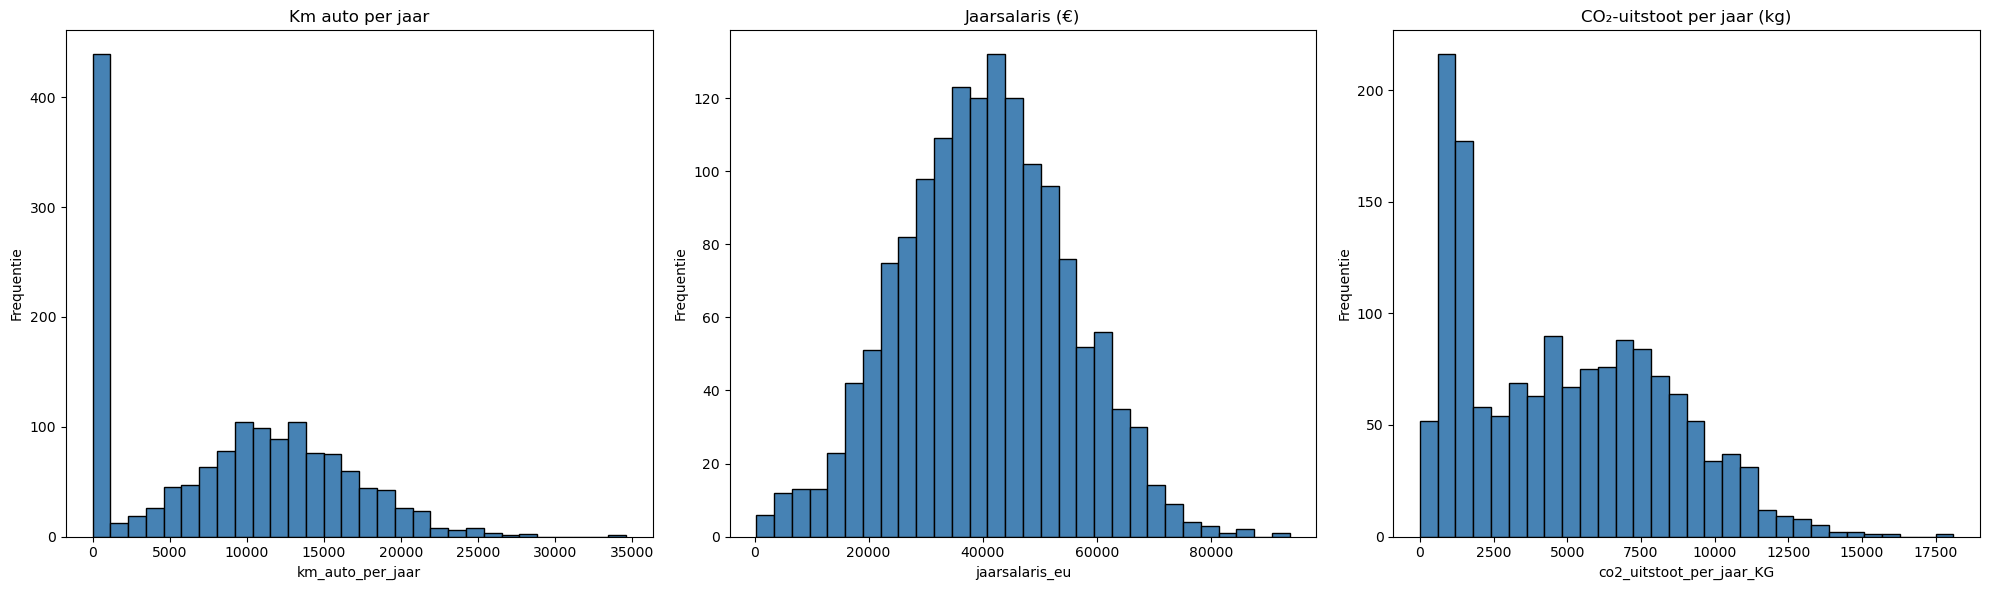

In [32]:
variabelen = ["km_auto_per_jaar", "jaarsalaris_eu", "co2_uitstoot_per_jaar_KG"]
titels     = ["Km auto per jaar", "Jaarsalaris (€)", "CO₂-uitstoot per jaar (kg)"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, col, titel in zip(axes, variabelen, titels):
    ax.hist(df[col], bins=30, edgecolor="black", color="steelblue")
    ax.set_title(titel)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequentie")

plt.tight_layout()
plt.show()

### Python 4.L Python: Toets, met behulp van statistiek, of de verdelingen (vraag 4) normaal verdeeld zijn. 

In [53]:
variabelen = ["km_auto_per_jaar", "jaarsalaris_eu", "co2_uitstoot_per_jaar_KG"]


for col in variabelen:
    data = df[col].dropna()
    stat, p = stats.shapiro(data)
    
    if p > 0.05:
        conclusie = "Normaal verdeeld (H₀ niet verworpen)"
    else:
        conclusie = "Niet normaal verdeeld (H₀ verworpen)"
    
    print(f"{col}")
    print(f"p-waarde: {p:.2f}")
    print(f"Conclusie: {conclusie}")
    print("\n")


km_auto_per_jaar
p-waarde: 0.00
Conclusie: Niet normaal verdeeld (H₀ verworpen)


jaarsalaris_eu
p-waarde: 0.50
Conclusie: Normaal verdeeld (H₀ niet verworpen)


co2_uitstoot_per_jaar_KG
p-waarde: 0.00
Conclusie: Niet normaal verdeeld (H₀ verworpen)


